Add your kaggle.json file which contains your kaggle api key to directly access kaggle for datasets rather than downloading it and add it to the project. (located in C:\ Users \ "your name" \ .kaggle (for windows idk mac)


First step is to initialize the datasets. Some datasets are too large for us to download and import into colab so instead we will import them directly from Kaggle itself. To do that we need to do the following:

1. Follow this path in your folder: C:\ Users \ "your name" \ .Kaggle (idk for mac ask chatgpt). Inside the .Kaggle folder you will get a Kaggle.json file which will contain an api key which will allow you to access Kaggle. Since i used to work on Kaggle before i had this already, but you can ask chatgpt how to get the api key to access Kaggle.

2. Then we will install Kaggle related dependencies

3. We are configuring the Kaggle.json file

4. Downloading the dataset

5. unzipping the dataset

6. Listting extracted datasets

In [1]:
#step 1
from google.colab import files
files.upload()

#step 2
!pip install -q kaggle

#step 3
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


#Step 4
!kaggle competitions download -c ieee-fraud-detection

#step 5
!unzip ieee-fraud-detection.zip

#step 6
!ls

Saving kaggle.json to kaggle.json
100% 118M/118M [00:03<00:00, 33.7MB/s]

Archive:  ieee-fraud-detection.zip
  inflating: sample_submission.csv   
  inflating: test_identity.csv       
  inflating: test_transaction.csv    
  inflating: train_identity.csv      
  inflating: train_transaction.csv   
ieee-fraud-detection.zip  sample_submission.csv  train_identity.csv
kaggle.json		  test_identity.csv	 train_transaction.csv
sample_data		  test_transaction.csv


7. import important libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

8. File is large, so load a subset first and perform basic dataset inspections

In [25]:
df = pd.read_csv("train_transaction.csv", nrows=200000)

df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 601.2+ MB


9. Dataset contains a "isFraud" field which basically says true or false. we load it to see how many fraud and how many non fraud are there. Basically visualize it

In [10]:
df['isFraud'].value_counts()

,count
isFraud,
0,193976
1,6024


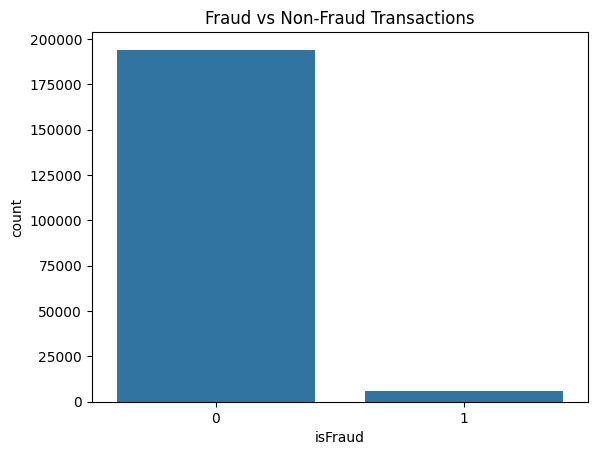

In [11]:
df['isFraud'].value_counts()
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

10. Dataset has a lot of missing values. We find out which columns ones have missing values

In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

,0
D7,187224
dist2,184481
D13,179592
D14,177761
D12,177263
D6,173705
D9,164684
D8,164684
M7,162910
M8,162910


11. Basic statistics definitions

In [13]:
df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,2.000000e+05,200000.000000,2.000000e+05,200000.000000,200000.000000,196974.000000,199997.000000,198933.000000,178608.000000,178608.000000,...,49536.000000,49536.000000,49536.000000,49536.00000,49536.000000,49536.000000,49536.000000,49536.000000,49536.000000,49536.000000
mean,3.087000e+06,0.030120,2.143828e+06,129.828889,9863.299370,367.834450,153.307935,200.397968,291.099357,86.600589,...,0.142967,74.446599,99.128524,85.32945,8.245387,18.785890,12.416170,27.055076,32.283990,28.763268
std,5.773517e+04,0.170918,1.211275e+06,207.672259,4914.176565,158.879956,11.440031,40.543277,102.160483,3.782374,...,0.673265,537.925329,659.448913,569.61555,83.565437,120.837793,98.357384,250.356551,281.972665,255.974114
min,2.987000e+06,0.000000,8.640000e+04,0.292000,1001.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.037000e+06,0.000000,1.189346e+06,43.925000,6019.000000,215.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.087000e+06,0.000000,2.006390e+06,74.000000,9633.000000,375.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.136999e+06,0.000000,3.093420e+06,125.000000,14182.000000,514.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.186999e+06,1.000000,4.556419e+06,5278.950000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,15.000000,20750.000000,32250.000000,21250.00000,3100.000000,3350.000000,3250.000000,8250.000000,8250.000000,8250.000000


12. inspecting target variable

In [14]:
fraud_rate = df['isFraud'].mean()
print("Fraud rate:", fraud_rate)

Fraud rate: 0.03012


13. Check key columns like:
TransactionAmt
ProductCD
card1
card2
card3
addr1
addr2

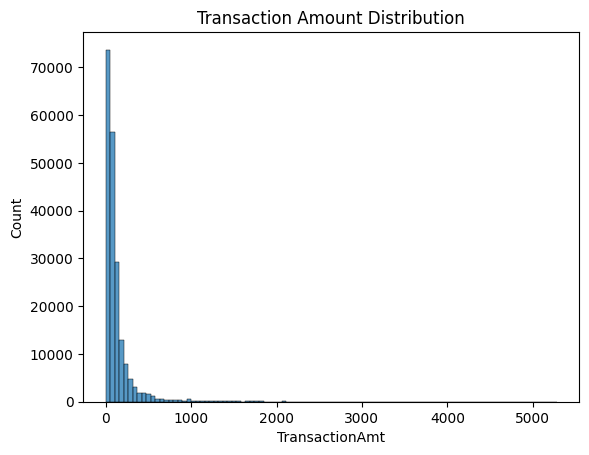

In [15]:
sns.histplot(df['TransactionAmt'], bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

14. Merge datasets
train_transaction + train_identity

In [16]:
identity = pd.read_csv("train_identity.csv")
df_full = df.merge(identity, on="TransactionID", how="left")

In [17]:
df_full.shape
df_full.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


15. Confirm the Target Variable

In [18]:
df_full["isFraud"].value_counts()


,count
isFraud,
0,193976
1,6024


In [19]:
df_full["isFraud"].mean()

np.float64(0.03012)

16. Inspect Missing Values

In [20]:
missing = df_full.isnull().sum().sort_values(ascending=False)
missing.head(20)

,0
id_24,197616
id_25,197448
id_21,197440
id_08,197439
id_07,197439
id_26,197437
id_27,197436
id_23,197436
id_22,197436
D7,187224


In [21]:
missing_pct = (df_full.isnull().sum() / len(df_full)) * 100
missing_pct.sort_values(ascending=False).head(20)

,0
id_24,98.8080
id_25,98.7240
id_21,98.7200
id_08,98.7195
id_07,98.7195
id_26,98.7185
id_27,98.7180
id_23,98.7180
id_22,98.7180
D7,93.6120


17. Drop Very Sparse Columns. Columns with >90% missing values usually hurt models.

In [22]:
cols_to_drop = missing_pct[missing_pct > 90].index

df_full = df_full.drop(columns=cols_to_drop)

In [23]:
df_full.shape

(200000, 423)

18. Separate Feature Types. We need to identify categorical vs numerical columns.

In [24]:
categorical_cols = df_full.select_dtypes(include=["object"]).columns
numerical_cols = df_full.select_dtypes(exclude=["object"]).columns
print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 29
Numerical: 394
